
#  **Customer Segmentation Analysis using Clustering Algorithms**

## **1. using PCA + K-Means Clustering**

## **Business Question**
### **How can we segment customers based on **income** and **spending behavior** to improve targeted marketing strategies?**



In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans # This imports/allows to use/fit the KMEANS CLUSTERING ALGORITHM
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [2]:

df = pd.read_csv('Mall_Customers.csv')

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:

# information about dataset including column names and data types
df.info()

#summary statistics of numerical columns
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
#checking for the cleanliness of my data
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:

# Selecting only relevant features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [6]:

# Initializing StandardScaler to scale features
scaler = StandardScaler()

# Fitting scaler to data and transform features
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [7]:

# Initializing PCA to reduce dimensions to 2 components
pca = PCA(n_components=2)

# Applying PCA transformation on scaled data
X_pca = pca.fit_transform(X_scaled)

# variance explained by each principal component
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.50495142 0.49504858]


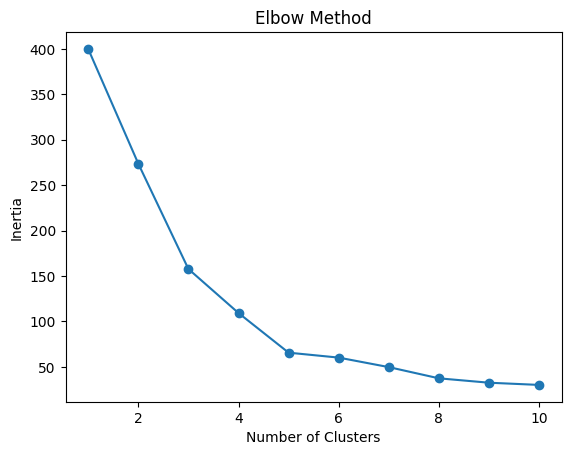

In [8]:

# Initializing empty list to store inertia values
inertia = []  # Inertia = how tightly grouped the data points are within each cluster
#It is the sum of squared distances between:
#1. each data point
#2. and its cluster centroid

# Looping over different numbers of clusters Because K-Means does NOT know the best number of clusters (K) — we have to find it ourselves.
for k in range(1, 11):  #groups the data into cluster 1..cluster 2.. etc upto cluster 10

    # Initializing KMeans with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fitting model on PCA_transformed data
    kmeans.fit(X_pca)

    # Appending inertia value to list
    inertia.append(kmeans.inertia_)

# Plotting elbow curve to determine optimal k
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


**The Elbow Method** is a technique used to determine the optimal number of clusters (K) in K-Means clustering.

In [9]:

# Initializing KMeans with optimal number of clusters (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)

# Fitting model and predict cluster labels
labels = kmeans.fit_predict(X_pca)

# Adding cluster labels to original DataFrame
df['Cluster'] = labels

# Displaying updated dataset
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


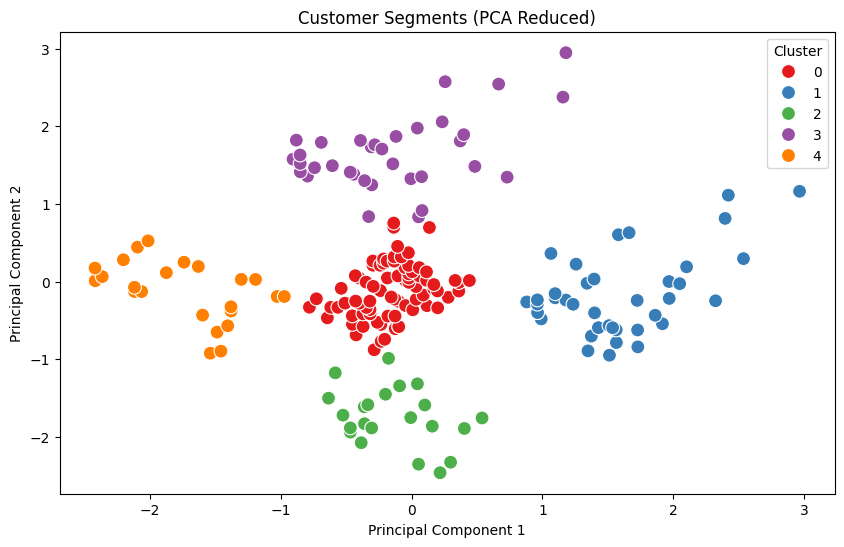

In [10]:

# Visualizing clusters using PCA components
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'],palette='Set1', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments (PCA Reduced)')
plt.show()


In [11]:
# Calculating Silhouette Score (measures cluster separation)
sil_score = silhouette_score(X_pca, labels)# This calculates How well each data point fits into its cluster compared to other clusters
print("Silhouette Score:", sil_score)


Silhouette Score: 0.5546571631100179


**Interpretation of the silhouette score**

Customers in each segment are fairly/averagely well grouped

Clusters are reasonably separated

Not perfect, but good enough for business use

**Customers in the same cluster behave similarly, and clusters are distinct enough to be targeted differently.**

In [12]:
# Calculating Davies-Bouldin Index (How similar clusters are to each other)
db_score = davies_bouldin_score(X_pca, labels)
print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 0.5722356162263352


**interpretation of the Davis-Bouldin score**

- Clusters are well separated

- Not too much overlap

**Customer segments are clearly different, so strategies for each group will not conflict.**

In [13]:
# Calculating Calinski-Harabasz Score (ratio of between-cluster dispersion)
#High Calinski-Harabasz score means GOOD CLUSTERING, Low means BAD CLUSTERING
ch_score = calinski_harabasz_score(X_pca, labels)



print("Calinski-Harabasz Score:", ch_score)


Calinski-Harabasz Score: 248.64932001536354


**interpretation of Calinski-Harabasz score**

Clusters are:

- tight internally

- well separated externally

**Each customer segment is distinct and meaningful**

In [14]:

# Grouping dataset by cluster and compute mean values for profiling
cluster_profile = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Displaying cluster profiling table
cluster_profile


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043



## Business Interpretation

- **Cluster 0** → moderate income, moderate spending
- **Cluster 1** → High income, high spending → premium customers
- **Cluster 2** → Low income, high spending → Promotion-driven buyers  
- **Cluster 3** → high income, low spending → Budget customers  
- **Cluster 4** → low income, low spending → Balanced segment group

## Conclusion

This analysis successfully segments customers using PCA and KMeans.  
The insights can help businesses improve targeting, retention, and revenue strategies.


## **2. Using HIERARCHICHAL CLUSTERING**

In [15]:
#HIERACHICHAL CLUSTERING ALGORITHMS
import scipy.cluster. hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

a. creating a dendrogram for dfinding the optimal number of clusters

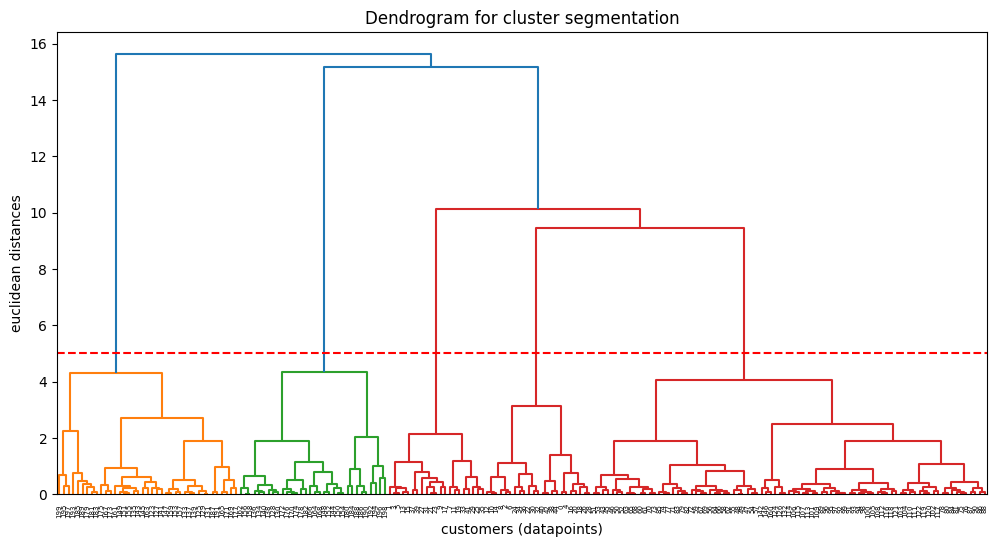

In [16]:
# a Dendrogram to find the optimal number of clusters
plt.figure(figsize=(12,6))

# Using 'ward' linkage to minimize variance within clusters
dendrogram=sch.dendrogram(sch.linkage(X_pca, method='ward'))
plt.title('Dendrogram for cluster segmentation')
plt.xlabel('customers (datapoints)')
plt.ylabel('euclidean distances')
plt.axhline(y=5, color='r',linestyle='--') # visual aid for the 5 cluster cut
plt.show()


**dendogram interpretation**

- The red line intersects 5 vertical branches. This mathematically confirms that 5 clusters is an optimal choice for segmenting these customers, which aligns with the k=5 used in the K-Means analysis.

- **Significant Splits:** The large blue vertical lines at the top indicate very distinct, broad groups of customers.

- **Sub-Segments:** The smaller orange and green clusters at the bottom indicate sub-groups that are very similar to one another.

b. Fitting the Agglomerative Clustering

In [17]:
# We use 5 clusters to stay consistent with the K-Means business logic
hc=AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_labels=hc.fit_predict(X_pca)

C. Adding Hierarchical labels to your DataFrame for comparison

In [18]:
df['HC_Cluster']=hc_labels
df['HC_Cluster'].head()

0    4
1    3
2    4
3    3
4    4
Name: HC_Cluster, dtype: int64

c. Visualizing the Hierarchical Segments

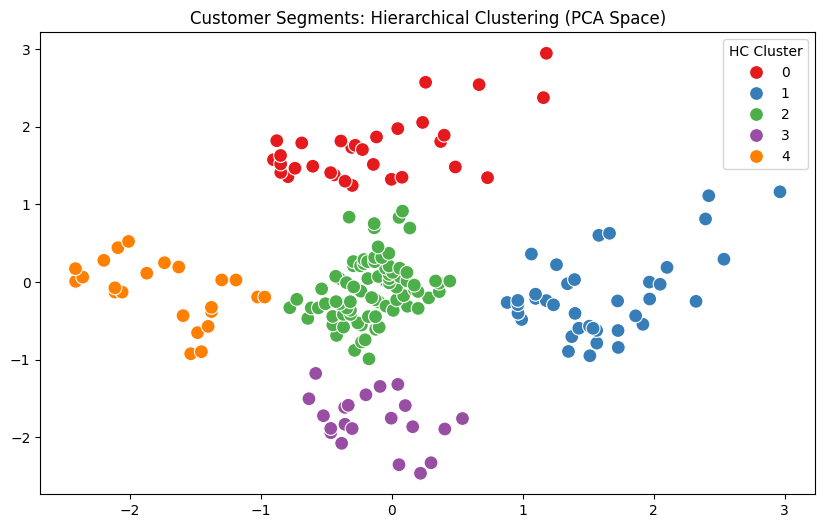

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:, 0],y=X_pca[:, 1],hue=df['HC_Cluster'], palette='Set1', s=100)
plt.title('Customer Segments: Hierarchical Clustering (PCA Space)')
plt.legend(title='HC Cluster')
plt.show()

d. Business Profiling for Hierarchical Clusters

In [20]:
hc_profile=df.groupby('HC_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Average Metrics per Hierarchical Cluster:")
print(hc_profile)

Average Metrics per Hierarchical Cluster:
            Annual Income (k$)  Spending Score (1-100)
HC_Cluster                                            
0                    89.406250               15.593750
1                    86.538462               82.128205
2                    55.811765               49.129412
3                    25.095238               80.047619
4                    26.304348               20.913043


**Interpretation of the Clusters to answer the business question**

- **cluster 0**-- high income, Low spenders= budget spenders

- **cluster1**--high income, high spenders= premium customers

- **cluster2**--moderate income, moderate spenders

- **cluster3**--low income, high spenders= promotional driven buyers

- **cluster4**--low income, low spenders= balanced customers

e. evaluation of the hierarchichal model

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculating metrics for Hierarchical Clustering
hc_sil = silhouette_score(X_pca, hc_labels)
hc_db = davies_bouldin_score(X_pca, hc_labels)
hc_chs=calinski_harabasz_score(X_pca,hc_labels )

print(f"Hierarchical Silhouette Score: {hc_sil:.3f}")
print(f"Hierarchical Davies-Bouldin Index: {hc_db:.3f}")
print(f"Hierarchical calinski_harabasz_score: {hc_chs:.3f} ")

Hierarchical Silhouette Score: 0.554
Hierarchical Davies-Bouldin Index: 0.578
Hierarchical calinski_harabasz_score: 244.410 


A **Silhouette score** of **0.554** is considered a strong, structured result. It means that the majority of the customers are much closer to other members of their own cluster than they are to members of a neighboring cluster.

- **Business Interpretation:** There is very little "identity crisis" in the segments. If the model says a customer is a "High Spender," there is a low mathematical chance they actually belong in the "Frugal" group. The targeted ads are unlikely to be sent to the wrong person.

A Davies-Bouldin Index score of **0.578 is very low**, which is **excellent**. It signifies that the clusters are "tight" (low internal spread) and "well-spaced" (large distance between cluster centers).

- **Technical Context:** Usually, **a Davies-Bouldin Index below 1.0 is the gold standard for clustering**. Having a score nearly half of that indicates that the use of PCA (Principal Component Analysis) successfully removed the noise from the original dataset, allowing the hierarchical algorithm to find very clean boundaries.

**calinski_harabasz_score** score of **244.410** means the "between-cluster" variance is significantly higher than the "within-cluster" variance.  
- The five customer groups are very different from each other, but the people inside each group are very similar to one another.
- **High** calinski_harabasz_score confirms a clear mathematical split between segments.

#### **Overall Interpretation of Hierarchichal cluster algorithm**

The model achieved a **Silhouette Score of 0.554** and a **Davies-Bouldin Index of 0.578**, indicating **high cluster stability and clear separation**. Mathematically, this confirms that the 5 identified customer segments are distinct enough to justify five different marketing approaches. We are not just guessing; the data shows that these customer behaviors are naturally grouped and highly predictable.

## **3.FINAL BUSINESS CONCLUSION**

**High Confidence:** With a Silhouette score above 0.5 and a Davies-Bouldin index well below 1.0, these segments are distinct enough that THE MODEL won't accidentally target a "Frugal" customer with "Premium" luxury ads.

**Scalability:** Because K-Means performed so similarly to Hierarchical clustering, the business can use the faster K-Means algorithm to automatically categorize thousands of new customers in real-time as they join the database.





## **4. TESTING THE MODEL WITH NEW DATA TO DETERMINE CUSTOMER CLUSTER**

a.  Defining the number of new customers to generate

In [22]:

n_new_customers = 50 

# 2. Generating random but realistic data based on the original dataset's ranges
np.random.seed(42) # For reproducibility

new_data = pd.DataFrame({
    'CustomerID': range(201, 201 + n_new_customers),
    'Gender': np.random.choice(['Male', 'Female'], n_new_customers),
    'Age': np.random.randint(18, 70, n_new_customers),
    'Annual Income (k$)': np.random.randint(15, 140, n_new_customers),
    'Spending Score (1-100)': np.random.randint(1, 100, n_new_customers)
})

# 3. Saving to a new CSV file
new_data.to_csv('New_Mall_Customers_Test.csv', index=False)

print(f"Successfully generated {n_new_customers} new customer records.")
print(new_data.head())

Successfully generated 50 new customer records.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0         201    Male   64                 101                      34
1         202  Female   68                 138                      33
2         203    Male   61                 135                      48
3         204    Male   69                  76                      23
4         205    Male   20                  54                      62


b. Loading the new test data

In [23]:
# 1. Load the new data
df_new = pd.read_csv('New_Mall_Customers_Test.csv')

# 2. Preprocess (Scale and PCA) 
# IMPORTANT: Use .transform(), NOT .fit_transform()
X_new = df_new[['Annual Income (k$)', 'Spending Score (1-100)']]
X_new_scaled = scaler.transform(X_new) 
X_new_pca = pca.transform(X_new_scaled)

c. predicting the clusters using the trained kmeans model

In [24]:
new_labels = kmeans.predict(X_new_pca)
new_labels


array([3, 3, 3, 3, 0, 1, 3, 1, 3, 1, 1, 4, 2, 1, 3, 1, 3, 3, 4, 2, 4, 0,
       3, 1, 3, 2, 3, 2, 1, 2, 1, 0, 2, 3, 1, 4, 4, 0, 4, 3, 4, 3, 1, 1,
       2, 4, 2, 3, 3, 2], dtype=int32)

d. adding numeric cluster columns

In [25]:
df_new['Cluster_ID'] = new_labels
df_new['Cluster_ID'].head()

0    3
1    3
2    3
3    3
4    0
Name: Cluster_ID, dtype: int32

e. Mapping IDs to business personas based on cluster interpretation 

In [26]:
cluster_map = {
    0: "Premium (High Income, High Spend)",
    1: "Untapped Potential (High Income, Low Spend)",
    2: "Promotion-Driven (Low Income, High Spend)",
    3: "Budget (Low Income, Low Spend)",
    4: "Balanced (Average Income, Average Spend)"
}

df_new['Customer_Segment'] = df_new['Cluster_ID'].map(cluster_map)
df_new['Customer_Segment'].head()


0       Budget (Low Income, Low Spend)
1       Budget (Low Income, Low Spend)
2       Budget (Low Income, Low Spend)
3       Budget (Low Income, Low Spend)
4    Premium (High Income, High Spend)
Name: Customer_Segment, dtype: str

f. saving the final segment list to csv

In [27]:
df_new.to_csv('Final_Segment_Customers.csv',index=False)

g. final result display

In [28]:
print("First 10 New Customers with their Assigned Segments:")
df_new[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Customer_Segment']].head(10)

First 10 New Customers with their Assigned Segments:


,CustomerID,Annual Income (k$),Spending Score (1-100),Customer_Segment
0,201,101,34,"Budget (Low Income, Low Spend)"
1,202,138,33,"Budget (Low Income, Low Spend)"
2,203,135,48,"Budget (Low Income, Low Spend)"
3,204,76,23,"Budget (Low Income, Low Spend)"
4,205,54,62,"Premium (High Income, High Spend)"
5,206,99,88,"Untapped Potential (High Income, Low Spend)"
6,207,94,37,"Budget (Low Income, Low Spend)"
7,208,123,99,"Untapped Potential (High Income, Low Spend)"
8,209,96,44,"Budget (Low Income, Low Spend)"
9,210,125,86,"Untapped Potential (High Income, Low Spend)"


visuals of the clusters display

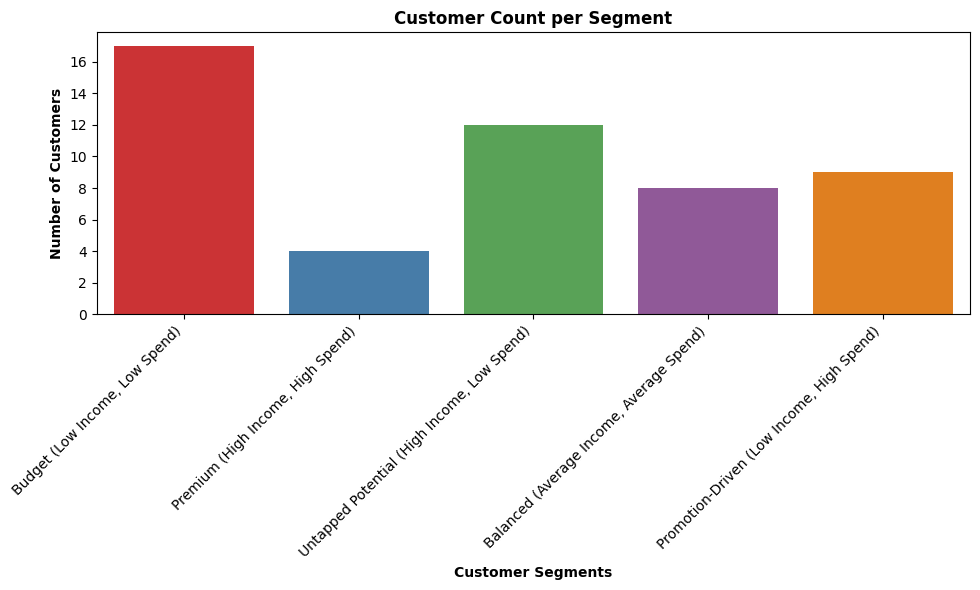

In [42]:
plt.figure(figsize=(10, 6))

#countplot automatically counts the CustomerIDs 
sns.countplot(data=df_new, x='Customer_Segment', palette='Set1', hue='Customer_Segment', legend=False)


plt.title('Customer Count per Segment', fontweight='bold')
plt.xlabel('Customer Segments', fontweight='bold')
plt.ylabel('Number of Customers', fontweight='bold')


plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()

### **f. Getting cluster for specific customer**

In [39]:
target_id = 205 

customer_info = df_new[df_new['CustomerID'] == target_id]

if not customer_info.empty:
    segment = customer_info['Customer_Segment'].values[0]
    income = customer_info['Annual Income (k$)'].values[0]
    spend = customer_info['Spending Score (1-100)'].values[0]
    
    print(f"--- Search Result for ID {target_id} ---")
    print(f"Segment: {segment}")
    print(f"Annual Income: ${income}k")
    print(f"Spending Score: {spend}/100")
else:
    print(f"CustomerID {target_id} not found in the new dataset.")

--- Search Result for ID 205 ---
Segment: Premium (High Income, High Spend)
Annual Income: $54k
Spending Score: 62/100
